# RR Array：多模态瑞利波分离与三台干涉去噪

## 1. 案例目标

高频背景噪声互相关函数（ambient-noise cross-correlation，ANC）通常具有较低的信噪比。在线性密集台阵中，三台干涉（three-station interferometry，TSI）可以利用直达面波在不同台站组合中稳定的几何走时关系增强目标信号，同时压制随机噪声、散射波和其他非相干成分。

但是，TSI 本身不能自动区分不同面波模态。当基阶与高阶瑞利波在相同频带内共存且能量接近、或不同模态在不同台间距的互相关函数中分别占主导时，干涉计算会产生模态交叉项，去噪结果不再对应单一、明确的面波模态。因此，本案例遵循一条核心原则：

> **先根据极化特征和相速度差异分离模态，再对各模态分别进行三台干涉去噪。**

## 2. 研究区与数据

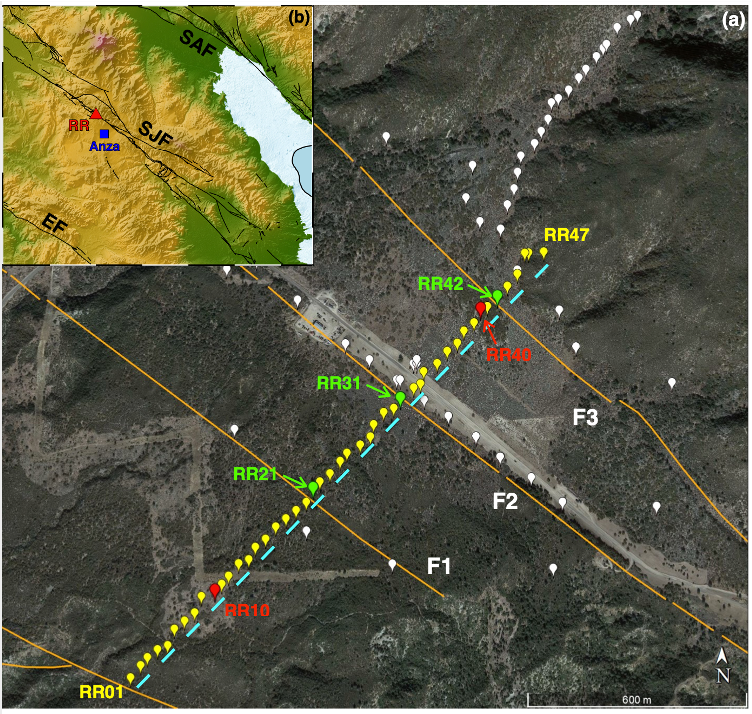

Ramona Reservation（RR）密集台阵位于美国南加州 Anza 地区，横跨 San Jacinto 断裂带 Clark 分支附近的多条地表断层迹线。完整台阵由 94 个三分量 5 Hz Fairfield 节点地震仪组成，连续记录时间约一个月。

本案例使用 RR01-RR47 子阵列。该子阵列：

- 近似沿一条直线排列；
- 平均台间距约 30 m；
- 阵列孔径约 1.6 km；
- 包含 ZZ、ZR、RZ 和 RR 四个与瑞利波相关的 ANC 分量；
- 同时发育基阶、第一高阶和更高阶瑞利波。

## 3. Step 0：导入程序并设置路径及默认参数

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt

from tsi_denoising import (
    Wavefield,
    MASW,
    DenoisingResult, 
    read_sac_directory,
    phase_match_separate,
    polarization_separate,
    denoise_station_pair_demo,
    denoise_wavefield_iteratively,
    plot_denoised_result
)

CASE_DIR = Path("./")
SAC_DIR = CASE_DIR / "input"
PROCESSED_DIR = CASE_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

if not SAC_DIR.is_dir():
    raise FileNotFoundError(
        f"输入数据目录不存在：{SAC_DIR.resolve()}\n"
        "请先在项目根目录运行 `python retrieve_datasets.py` 下载教学数据。"
    )

print(f"输入数据目录：{SAC_DIR.resolve()}")
print(f"缓存目录：{PROCESSED_DIR.resolve()}")


COMPONENTS = ("ZZ", "ZR", "RZ", "RR")
FMIN = 0.5; FMAX = 5.0 # Frequency bounds
VMIN = 0.1; VMAX = 2.5 # Moveout velocity bounds
EXAMPLE_PAIR = ("010", "040") # Example station pair for denoising demonstration
EXAMPLE_PERIODS = (0.8, 0.3) # Example periods for denoising demonstration

## 4. Step 1：读取并预处理四分量 ANC

`Wavefield.preprocess()` 依次完成：

1. 正负时间分支对称化；
2. 按 `distance / VMAX` 至 `distance / VMIN` 设置因果面波窗；
3. 在速度窗边界施加锥形过渡；
4. 进行 0.5-5.0 Hz 零相位带通滤波。

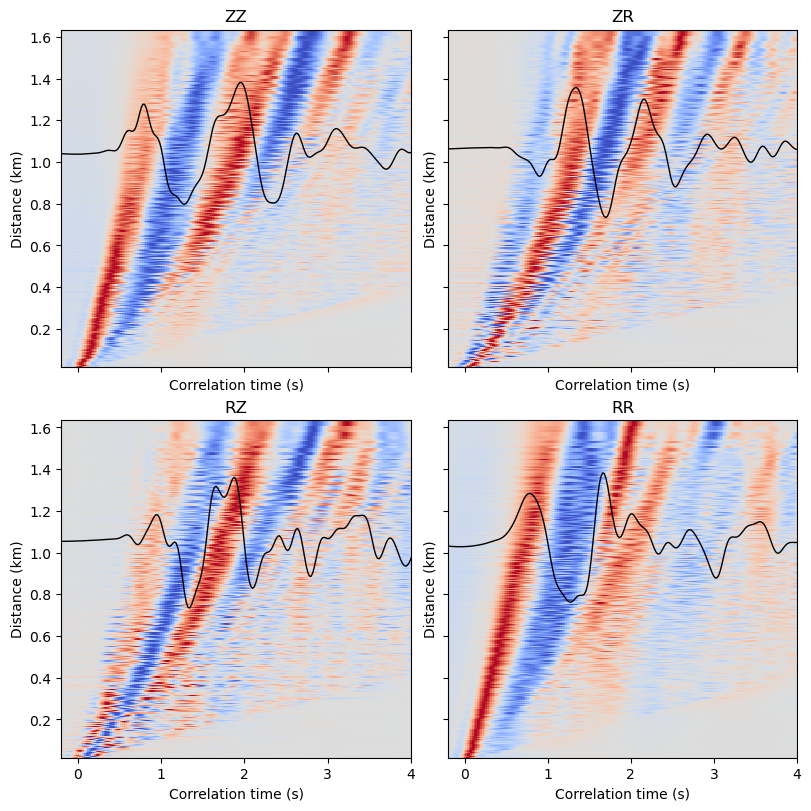

In [5]:
wavefields = {}
for component in COMPONENTS:
    cache_path = PROCESSED_DIR / f"{component.lower()}_wavefield.npz"
    if cache_path.exists():
        wavefields[component] = Wavefield.load(cache_path)
    else:
        wavefields[component] = read_sac_directory(SAC_DIR / component).preprocess()
        wavefields[component].save(cache_path, overwrite=True)

wfd_zz, wfd_zr, wfd_rz, wfd_rr = (wavefields[component] for component in COMPONENTS)

fig_wavefield, axes = plt.subplots(
    2, 2,
    figsize=(8, 8.),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)
for ax, component in zip(axes.ravel(), COMPONENTS):
    wavefields[component].plot(ax=ax, tshow_min=-0.2, tshow_max=4.0, example_pair=EXAMPLE_PAIR)
    ax.set_title(component)
plt.show()


## 5. Step 2：MASW 识别多模态频散能量

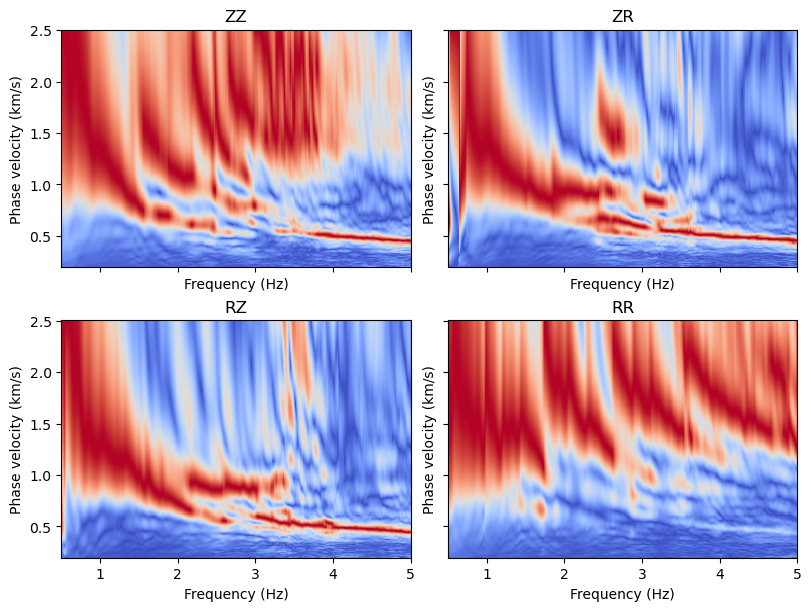

In [6]:

masw_results = {}
for component in COMPONENTS:
    cache_path = PROCESSED_DIR / f"{component.lower()}_masw.npz"
    if cache_path.exists():
        masw_results[component] = MASW.load(cache_path)
    else:
        masw_results[component] = MASW(wavefields[component]).compute()
        masw_results[component].save(cache_path)

masw_zz, masw_zr, masw_rz, masw_rr = (
    masw_results[component] for component in COMPONENTS
)

fig_dispersion, axes = plt.subplots(
    2, 2,
    figsize=(8, 6),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)
for ax, component in zip(axes.ravel(), COMPONENTS):
    masw_results[component].plot(ax=ax)
    ax.set_title(component)
plt.show()

## 6. Step 3：极化分离生成 M0 与 M1 候选
在本案例的坐标、径向方向和相关顺序约定下，基阶瑞利波主要表现为逆进运动，第一高阶瑞利波主要表现为顺进运动。交叉分量先经 Hilbert 变换补偿约 90 度相位差，再进行线性组合。

对每个台站对独立进行 RMS 归一化后，本案例使用：

$$
C_{\mathrm{M0,candidate}} =
\frac{\widehat C_{ZZ}
-H(\widehat C_{ZR})
+H(\widehat C_{RZ})
+\widehat C_{RR}}{4},
$$

$$
C_{\mathrm{M1,candidate}} =
\frac{\widehat C_{ZZ}
+H(\widehat C_{ZR})
-H(\widehat C_{RZ})
+\widehat C_{RR}}{4}.
$$


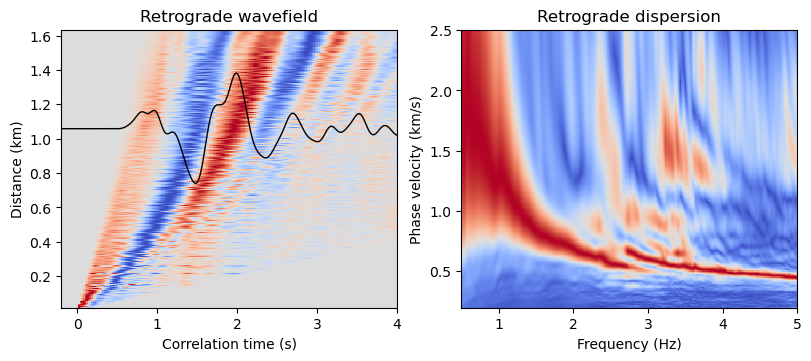

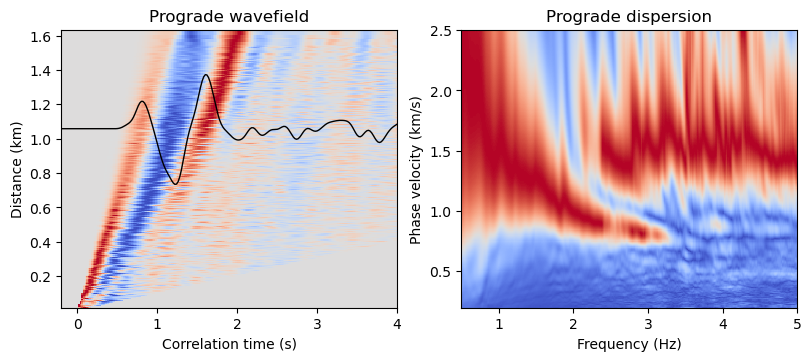

In [7]:
polarization_separated = polarization_separate(
    zz=wfd_zz,
    rz=wfd_rz,
    zr=wfd_zr,
    rr=wfd_rr,
    use_rr=True,
)

wfd_retrograde = polarization_separated["retrograde"]
wfd_prograde = polarization_separated["prograde"]
masw_retrograde = MASW(wfd_retrograde).compute(n_jobs=8)
masw_prograde = MASW(wfd_prograde).compute(n_jobs=8)

masw_retrograde.save(PROCESSED_DIR / f"retrograde_masw.npz", overwrite=True)
masw_prograde.save(PROCESSED_DIR / f"prograde_masw.npz", overwrite=True)

for mode, wavefield, masw in (
    ("Retrograde", wfd_retrograde, masw_retrograde),
    ("Prograde", wfd_prograde, masw_prograde),
):
    fig, axes = plt.subplots(
        1, 2,
        figsize=(8, 3.5),
        constrained_layout=True,
    )
    wavefield.plot(ax=axes[0], tshow_min=-0.2, tshow_max=4.0, example_pair=EXAMPLE_PAIR)
    masw.plot(ax=axes[1])
    axes[0].set_title(f"{mode} wavefield")
    axes[1].set_title(f"{mode} dispersion")
    plt.show()

## 7. Step 4：相位匹配获得单模态波场

In [10]:
%matplotlib qt
wfd_m0_separated = phase_match_separate(wfd_retrograde, masw_cache_path=PROCESSED_DIR / f"retrograde_masw.npz")


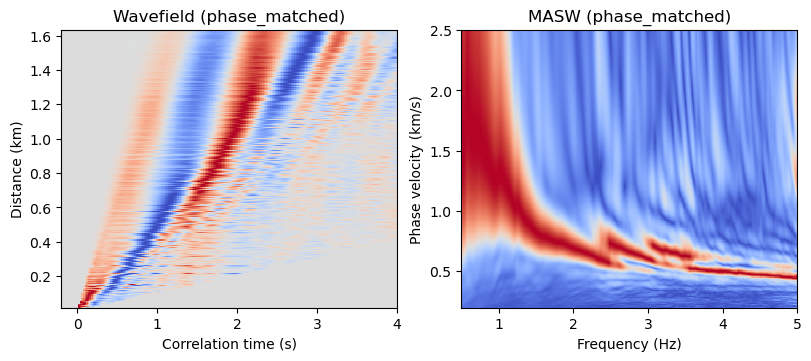

In [11]:
%matplotlib inline
masw_m0_separated = MASW(wfd_m0_separated).compute()
fig, axes = plt.subplots(
    1, 2,
    figsize=(8, 3.5),
    constrained_layout=True,
)
wfd_m0_separated.plot(ax=axes[0], tshow_min=-0.2, tshow_max=4.0)
masw_m0_separated.plot(ax=axes[1])
plt.show()

In [12]:
%matplotlib qt
wfd_m1_separated = phase_match_separate(wfd_prograde, masw_cache_path=PROCESSED_DIR / f"prograde_masw.npz")

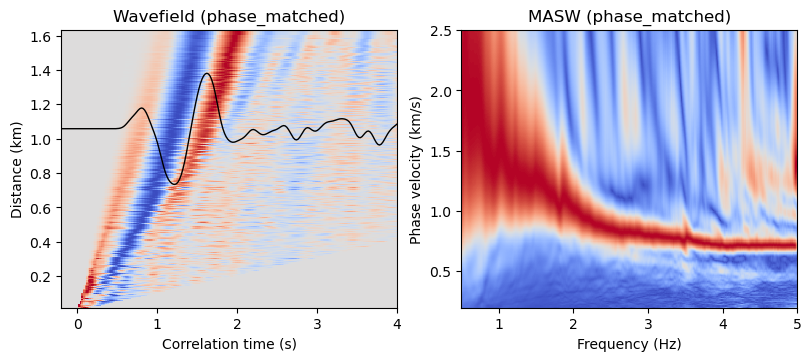

In [13]:
%matplotlib inline
masw_m1_separated = MASW(wfd_m1_separated).compute()
fig, axes = plt.subplots(
    1, 2,
    figsize=(8, 3.5),
    constrained_layout=True,
)
wfd_m1_separated.plot(ax=axes[0], tshow_min=-0.2, tshow_max=4.0, example_pair=EXAMPLE_PAIR)
masw_m1_separated.plot(ax=axes[1])
plt.show()

## 8. Step 5：分模态 TSI 诊断

(<Figure size 1000x850 with 8 Axes>,
 array([[<Axes: title={'center': 'Virtual shot gather at station 010'}, ylabel='Station number'>,
         <Axes: title={'center': 'Virtual shot gather at station 040'}>,
         <Axes: title={'center': 'Three-station interferometry'}>],
        [<Axes: xlabel='Correlation time (s)', ylabel='Station number'>,
         <Axes: xlabel='Correlation time (s)'>,
         <Axes: xlabel='Correlation time (s)'>]], dtype=object))

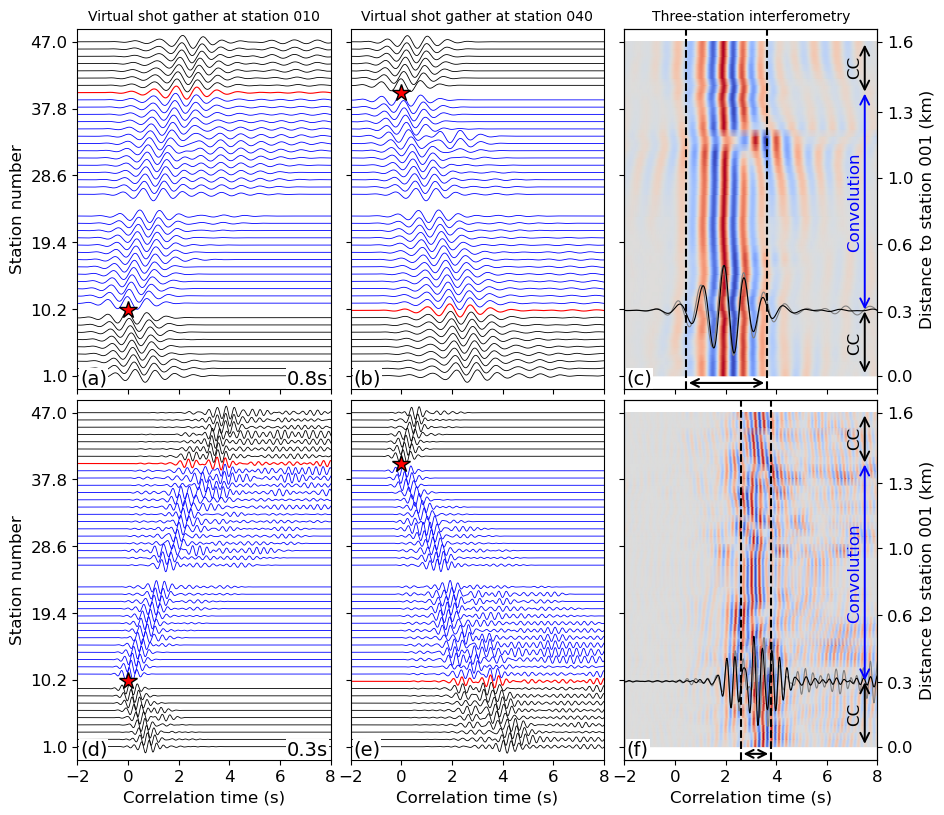

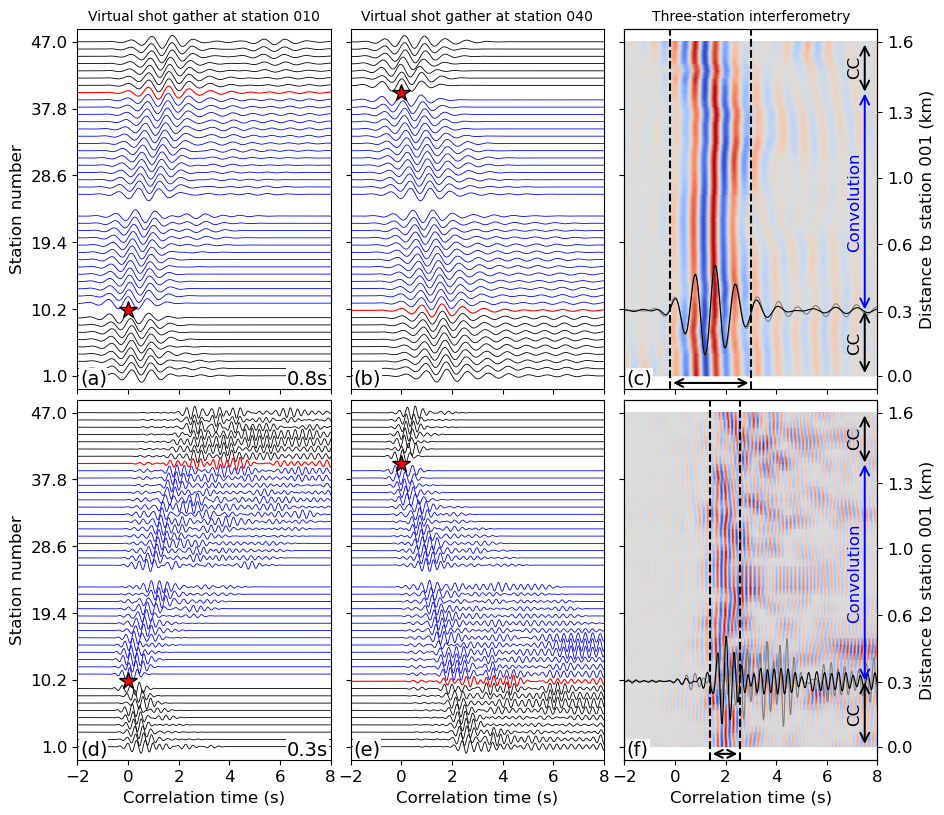

In [14]:
denoise_station_pair_demo(wfd_m0_separated, EXAMPLE_PAIR)
denoise_station_pair_demo(wfd_m1_separated, EXAMPLE_PAIR)

## 9. Step 6：分别迭代去噪 M0 与 M1

Loaded cached M0_Denoised denoising result.
Loaded cached M1_Denoised denoising result.


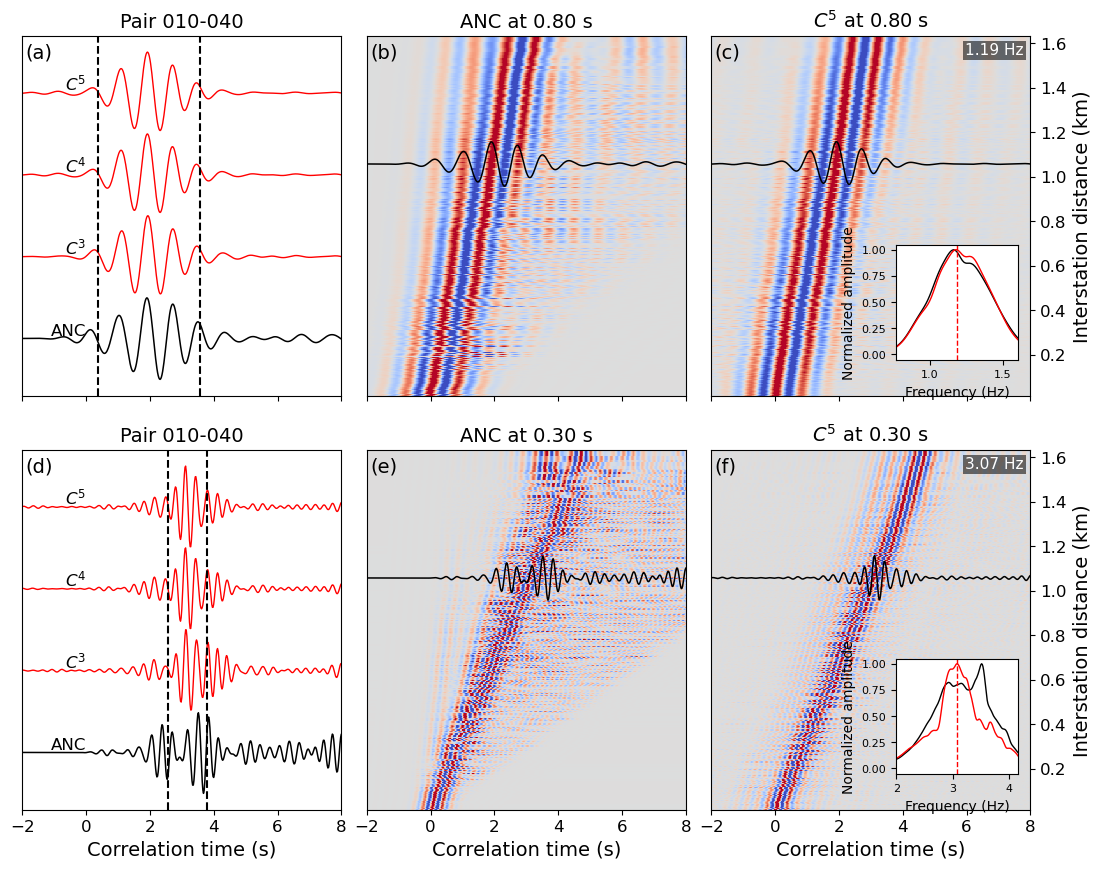

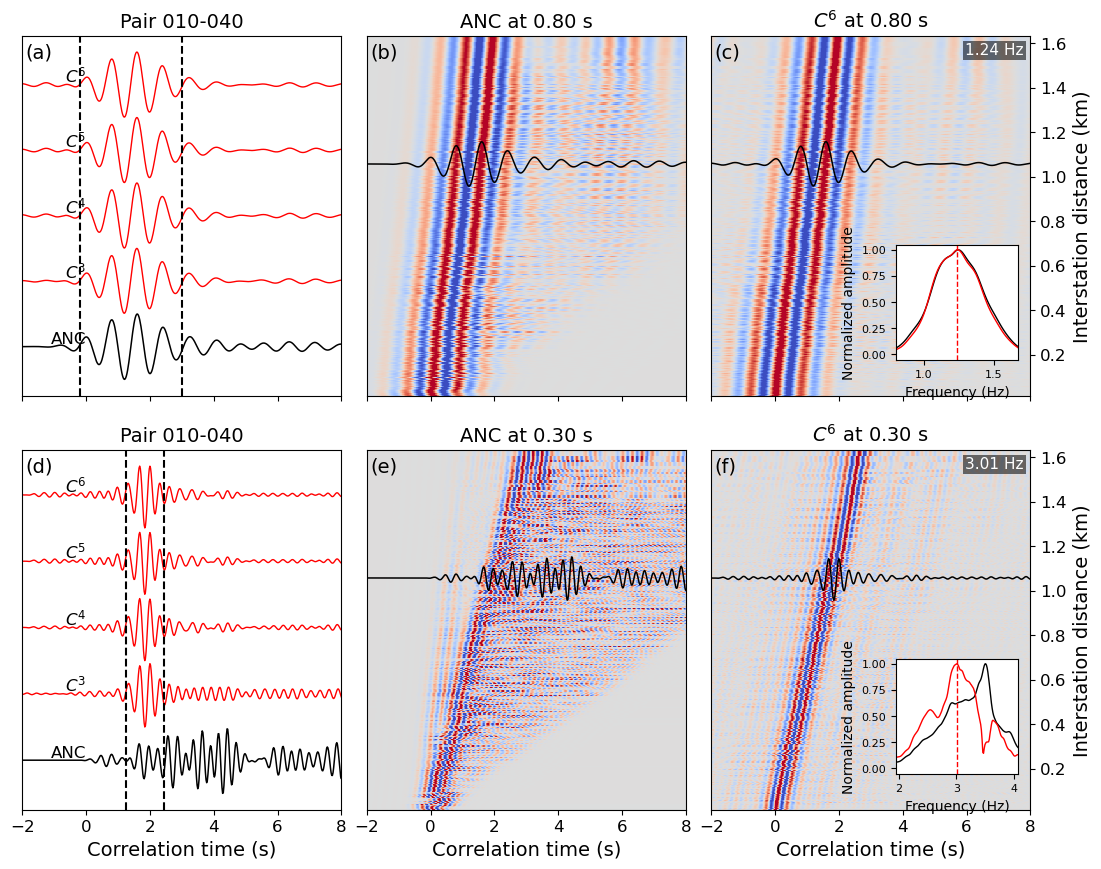

In [15]:

def load_or_denoise(wavefield, result_name):
    result_stem = PROCESSED_DIR / result_name
    wavefield_file = PROCESSED_DIR / f"{result_name}_wavefield.npz"
    info_file = PROCESSED_DIR / f"{result_name}_info.npz"

    if wavefield_file.exists() and info_file.exists():
        result = DenoisingResult.load(result_stem)
        print(f"Loaded cached {result_name} denoising result.")
    else:
        result = denoise_wavefield_iteratively(
            wavefield,
            EXAMPLE_PAIR,
            threshold=0.05,
            first_iteration_convolution=True,
            max_iterations=4,
            taper_output=False,
            n_jobs=8,
        )
        result.save(
            result_stem,
            overwrite=wavefield_file.exists() or info_file.exists(),
        )
        print(f"Computed and saved {result_name} denoising result.")

    return result


m0_denoised_result = load_or_denoise(wfd_m0_separated, "M0_Denoised")
m1_denoised_result = load_or_denoise(wfd_m1_separated, "M1_Denoised")

plot_denoised_result(
    wfd_m0_separated,
    m0_denoised_result,
    periods=EXAMPLE_PERIODS,
)
plot_denoised_result(
    wfd_m1_separated,
    m1_denoised_result,
    periods=EXAMPLE_PERIODS,
)
plt.show()

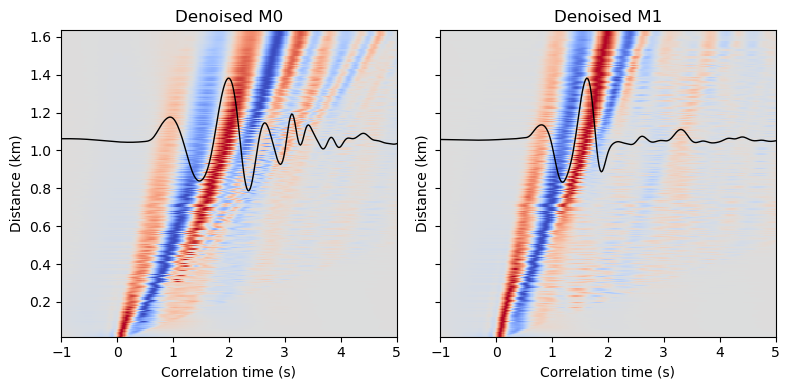

In [16]:
denoised_wavefield_m0=Wavefield.load(PROCESSED_DIR /"M0_Denoised_wavefield.npz").preprocess()
denoised_wavefield_m1=Wavefield.load(PROCESSED_DIR /"M1_Denoised_wavefield.npz").preprocess(vmax=3.)

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

denoised_wavefield_m0.plot(
    ax=axes[0],
    example_pair=EXAMPLE_PAIR,
    tshow_max=5,
    tshow_min=-1,
)
axes[0].set_title("Denoised M0")

denoised_wavefield_m1.plot(
    ax=axes[1],
    example_pair=EXAMPLE_PAIR,
    tshow_max=5,
    tshow_min=-1,
)
axes[1].set_title("Denoised M1")

plt.tight_layout()
plt.show()

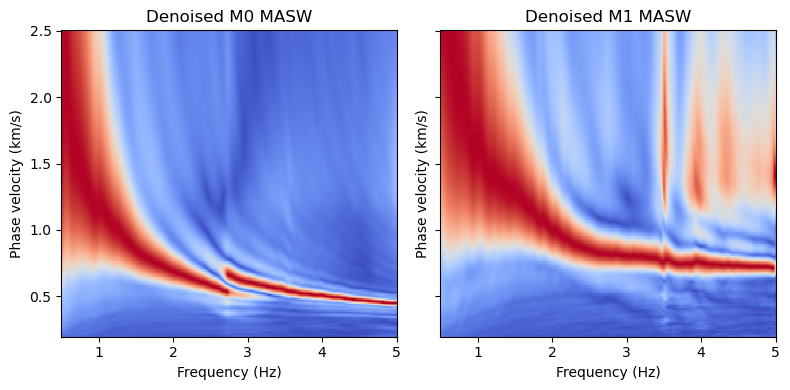

In [17]:
masw_m0 = MASW(
    denoised_wavefield_m0,
    fmin=FMIN,
    fmax=FMAX,
).compute(n_jobs=8)

masw_m1 = MASW(
    denoised_wavefield_m1,
    fmin=FMIN,
    fmax=FMAX,
).compute(n_jobs=8)

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

masw_m0.plot(ax=axes[0])
axes[0].set_title("Denoised M0 MASW")

masw_m1.plot(ax=axes[1])
axes[1].set_title("Denoised M1 MASW")

plt.tight_layout()
plt.show()